# Data Overview Report
This notebook summarizes the data you provided.
It covers two datasets:
- **Energy data** — electrical measurements from each GPU/Voie (Dec 2025 – Feb 2026)
- **Usage data** — daily AI model usage statistics (Oct 2025 – Feb 2026)

## 1. Library import

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
import json
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

## 2. Data import

#### 2.1 Energy Data

We concatenate the multiple energy CSV files into a single dataframe, aligned by GPU and sorted chronologically. The table shows one row per measurement per Voie.

In [2]:
files = glob.glob("101_*.csv")
data_frames = []
df_energy_fall = pd.read_csv("Energy_Data_Clean.csv")
data_frames.append(df_energy_fall)

for filename in files:
    df = pd.read_csv(filename, skiprows=1)
    parts = filename.split('_')
    df['GPU'] = parts[0] + '_' + parts[1] + '_' + parts[2]
    data_frames.append(df)
    df.rename(columns={'Time (UTC)': 'Datetime'}, inplace=True)
    
energy_df = pd.concat(data_frames, ignore_index=True)
energy_df['Datetime'] = pd.to_datetime(energy_df['Datetime'])
energy_df = energy_df.sort_values('Datetime').reset_index(drop=True)

energy_df

,GPU,Datetime,Input Voltage L1 (V),Input Voltage L2 (V),Input Voltage L3 (V),Input Voltage THD L1 (%),Input Voltage THD L2 (%),Input Voltage THD L3 (%),Input Frequency (Hz),Input Current L1 (A),...,Input Power Factor L3,Input Partial Energy Total (Wh),Input Partial Energy L1 (Wh),Input Partial Energy L2 (Wh),Input Partial Energy L3 (Wh),Input Cumulated Energy Total (Wh),Input Cumulated Energy L1 (Wh),Input Cumulated Energy L2 (Wh),Input Cumulated Energy L3 (Wh),Neutral Input Current (A)
0,101_K37_Voie1,2025-12-03 09:48:31+00:00,230.7,228.3,227.8,2.2,2.1,2.1,50.0,0.7,...,1.0,5010268.0,501889.0,2237345.0,2271034.0,5010268.0,501889.0,2237345.0,2271034.0,4.0
1,101_L37_Voie2,2025-12-03 09:50:36+00:00,231.8,229.9,230.8,1.9,2.5,2.0,50.0,0.9,...,1.0,11482249.0,1402737.1,5262549.0,4816962.0,11482249.0,1402737.1,5262549.0,4816962.0,1.8
2,101_K37_Voie1,2025-12-03 09:53:31+00:00,230.4,228.4,227.8,1.9,2.1,2.3,50.0,0.7,...,0.9,5010397.0,501900.0,2237399.0,2271098.0,5010397.0,501900.0,2237399.0,2271098.0,2.3
3,101_K37_Voie2,2025-12-03 09:55:24+00:00,231.7,229.7,230.3,2.4,1.8,2.3,50.0,0.8,...,1.0,11350389.0,1364751.1,4972482.0,5013155.0,11350389.0,1364751.1,4972482.0,5013155.0,2.1
4,101_L37_Voie1,2025-12-03 09:55:29+00:00,230.7,228.3,228.4,2.1,2.1,2.3,50.0,0.7,...,1.0,11189304.0,1150247.0,5247573.0,4791483.0,11189304.0,1150247.0,5247573.0,4791483.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33468,101_L37_Voie2,2026-02-17 11:02:41+00:00,230.7,229.0,229.5,2.2,2.8,2.6,50.0,0.9,...,1.0,13843860.0,1701007.1,6337058.5,5805794.5,13843860.0,1701007.1,6337058.5,5805794.5,2.0
33469,101_J37_Voie1,2026-02-17 11:04:07+00:00,231.1,228.2,226.6,2.0,1.8,2.0,50.0,0.8,...,1.0,13927571.0,1283283.0,5677402.5,6966885.5,13927571.0,1283283.0,5677402.5,6966885.5,6.6
33470,101_L37_Voie1,2026-02-17 11:06:14+00:00,231.1,228.2,228.0,2.1,2.0,2.1,50.0,0.8,...,1.0,13678494.0,1424955.1,6408061.5,5845477.5,13678494.0,1424955.1,6408061.5,5845477.5,2.1
33471,101_J37_Voie2,2026-02-17 11:06:16+00:00,231.0,229.4,228.4,2.4,2.8,2.6,50.0,0.9,...,1.0,4244365.0,365850.0,1357517.1,2520998.0,4244365.0,365850.0,1357517.1,2520998.0,6.5


### 2.2 Usage Data

In [3]:
dataframes = []
df_usage_fall = pd.read_csv("diane_usage_daily_with_models_2026-01-28 (2).csv")
dataframes.append(df_usage_fall)
df_usage_febuary = pd.read_csv("diane_usage_daily_with_models_fevrier.csv")
dataframes.append(df_usage_febuary)

usage_df = pd.concat(dataframes, ignore_index=True)
usage_df['Date'] = pd.to_datetime(usage_df['Date'])
usage_df = usage_df.sort_values('Date').reset_index(drop=True)

usage_df

,Date,Team,Team ID,Model,Spend ($),Requests,Successful,Failed,Total Tokens
0,2025-10-02,Unassigned,Unassigned,Qwen2.5-Coder-32B-Instruct-fp8-W8A16,0.0006,8,8,0,624
1,2025-10-02,Unassigned,Unassigned,Mistral-Small-24B-Instruct-2501-FP8-dynamic,0.0006,8,8,0,624
2,2025-10-02,Unassigned,Unassigned,Llama-3-3-70B-128k,0.0006,8,8,0,624
3,2025-10-02,Unassigned,Unassigned,/model/deepdml-faster-whisper-large-v3-turbo-ct2,0.0006,8,8,0,624
4,2025-10-03,Unassigned,Unassigned,/model/deepdml-faster-whisper-large-v3-turbo-ct2,0.0007,12,12,0,689
...,...,...,...,...,...,...,...,...,...
412,2026-02-24,default_user_id,default_user_id,gptoss120b,7.0072,4210,4210,0,7007204
413,2026-02-24,default_user_id,default_user_id,gptoss20b,7.0072,4210,4210,0,7007204
414,2026-02-24,Unassigned,Unassigned,/model/deepdml-faster-whisper-large-v3-turbo-ct2,0.0895,12450,12450,0,89504
415,2026-02-24,default_user_id,default_user_id,/model/deepdml-faster-whisper-large-v3-turbo-ct2,7.0072,4210,4210,0,7007204


## 3. Data visualisations

### 3.1 Data Coverage

The calendar shows which days have energy data, usage data, or both. Orange = overlap.

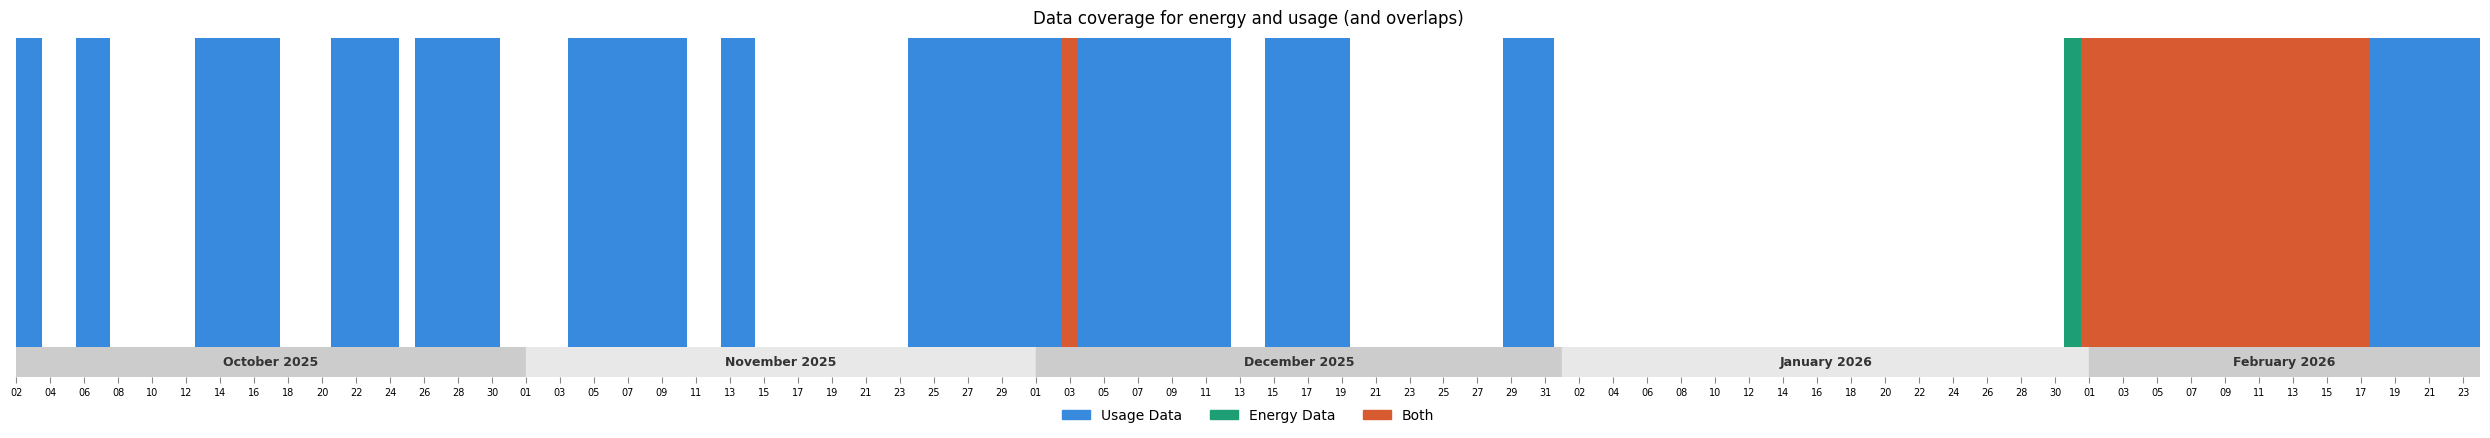

In [4]:
# Deduplicate to unique dates
usage_dates = pd.to_datetime(pd.Series(usage_df["Date"].unique()))
energy_dates = pd.to_datetime(pd.Series(energy_df["Datetime"].dt.date.unique()))

usage_set = set(usage_dates.dt.date)
energy_set = set(energy_dates.dt.date)

# Full date range
start = min(usage_dates.min(), energy_dates.min())
end = max(usage_dates.max(), energy_dates.max())
all_days = pd.date_range(start, end)

# Classify each day
colors = []
for d in all_days:
    u, e = d.date() in usage_set, d.date() in energy_set
    if u and e:
        colors.append("#D85A30")
    elif u:
        colors.append("#378ADD")
    elif e:
        colors.append("#1D9E75")
    else:
        colors.append("none")

months = pd.period_range(start=start, end=end, freq='M')
month_greys = ['#CCCCCC', '#E8E8E8']  # alternating light greys

fig, (ax, ax_months) = plt.subplots(
    2, 1, figsize=(25, 4.5),
    gridspec_kw={'height_ratios': [4, 0.4], 'hspace': 0}
)

# ── Top axis: data bars ──────────────────────────────────────────────────────
for d, c in zip(all_days, colors):
    if c != "none":
        ax.bar(d, 1, width=1, color=c, linewidth=0, zorder=2)

ax.set_xlim(all_days[0], all_days[-1])
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_title("Data coverage for energy and usage (and overlaps)", fontsize=12, pad=10)

# ── Bottom axis: grey month bands + day ticks ────────────────────────────────
for i, month in enumerate(months):
    m_start = max(month.start_time, pd.Timestamp(start))
    m_end   = min(month.end_time,   pd.Timestamp(end))
    ax_months.axvspan(m_start, m_end,
                      color=month_greys[i % 2],
                      zorder=0)

    mid = m_start + (m_end - m_start) / 2
    ax_months.text(mid, 0.5, month.strftime('%B %Y'),
                   ha='center', va='center',
                   fontsize=9, fontweight='bold', color='#333333')

ax_months.set_xlim(all_days[0], all_days[-1])
ax_months.set_ylim(0, 1)
ax_months.set_yticks([])
ax_months.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=2))
ax_months.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d"))
ax_months.tick_params(axis='x', labelsize=7, length=4, color='#888888')
plt.setp(ax_months.get_xticklabels(), rotation=0)
ax_months.spines[["top", "right", "left", "bottom"]].set_visible(False)

legend = [
    mpatches.Patch(color="#378ADD", label="Usage Data"),
    mpatches.Patch(color="#1D9E75", label="Energy Data"),
    mpatches.Patch(color="#D85A30", label="Both"),
]
ax_months.legend(handles=legend, loc="upper center", bbox_to_anchor=(0.5, -0.6),
                 ncol=3, frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

### 3.2 Requests and Tokens across time

Daily token counts (left axis, blue) and request counts (right axis, red) by day.

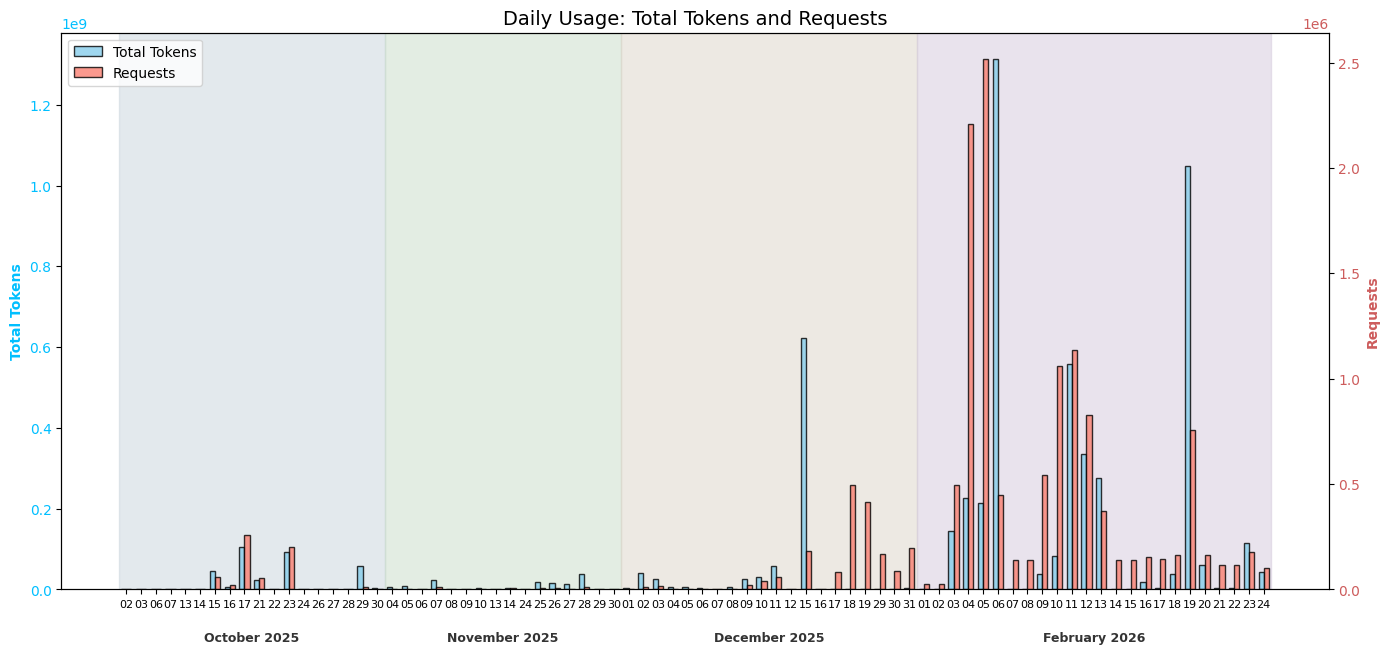

In [7]:
daily_usage = usage_df.groupby('Date').agg({
    'Total Tokens': 'sum',
    'Requests': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 7))
x = np.arange(len(daily_usage['Date']))
width = 0.35

# Bars
color_tokens = 'skyblue'
ax1.bar(x - width/2, daily_usage['Total Tokens'], width,
        label='Total Tokens', color=color_tokens, edgecolor='black', alpha=0.8)

ax2 = ax1.twinx()
color_requests = 'salmon'
ax2.bar(x + width/2, daily_usage['Requests'], width,
        label='Requests', color=color_requests, edgecolor='black', alpha=0.8)

# X-axis: show only day number, centered under each tick
ax1.set_xticks(x)
ax1.set_xticklabels(daily_usage['Date'].dt.strftime('%d'), rotation=0, fontsize=8)

# ── Month bands + labels ────────────────────────────────────────────────────
month_colors = ['#C9D4DC', '#C9DCC9', '#DCD4C9', '#D4C9DC']
dates = daily_usage['Date'].dt.to_period('M')
unique_months = dates.unique()

for i, month in enumerate(unique_months):
    mask = dates == month
    indices = x[mask.values]
    x_start = indices[0] - 0.5
    x_end   = indices[-1] + 0.5

    # Shaded background band
    ax1.axvspan(x_start, x_end,
                color=month_colors[i % len(month_colors)],
                alpha=0.5, zorder=0)

    # Month label centered on the band, just below the x-axis
    mid = (x_start + x_end) / 2
    ax1.annotate(
        month.strftime('%B %Y'),
        xy=(mid, 0), xycoords=('data', 'axes fraction'),
        xytext=(0, -30), textcoords='offset points',
        ha='center', va='top', fontsize=9, fontweight='bold', color='#333333'
    )

# Formatting
ax1.set_xlabel('', labelpad=30)
ax1.set_ylabel('Total Tokens', color='deepskyblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='deepskyblue')
ax2.set_ylabel('Requests', color='indianred', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='indianred')

plt.title('Daily Usage: Total Tokens and Requests', fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

### 3.3 Model use by number of tokens and requests

Total tokens and requests aggregated by model over the full period

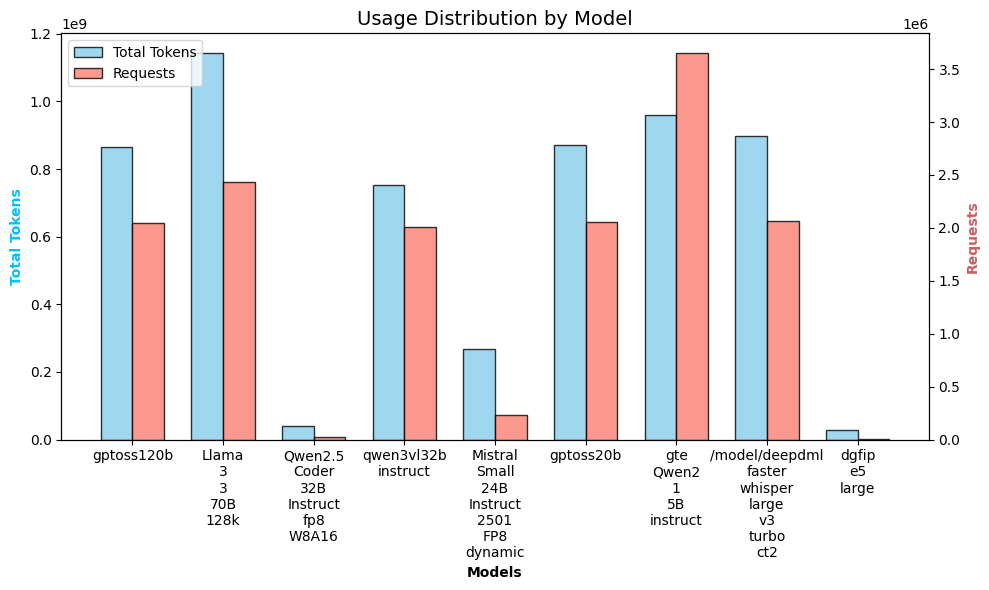

In [8]:
import textwrap

model_order = [
    'gptoss120b',
    'Llama-3-3-70B-128k',
    'Qwen2.5-Coder-32B-Instruct-fp8-W8A16',
    'qwen3vl32binstruct',
    'Mistral-Small-24B-Instruct-2501-FP8-dynamic',
    'gptoss20b',
    'gte-Qwen2-1-5B-instruct',
    '/model/deepdml-faster-whisper-large-v3-turbo-ct2',
    'dgfip-e5-large'
]

# 1. Group by 'Model' and sum metrics
model_usage = usage_df.groupby('Model').agg({
    'Total Tokens': 'sum',
    'Requests': 'sum'
}).reset_index()

# Reorder according to model_order (models not in the list go to the end)
model_usage['order'] = model_usage['Model'].map(
    {m: i for i, m in enumerate(model_order)}
)
model_usage = model_usage.sort_values('order').drop(columns='order').reset_index(drop=True)

# 2. Setup the plot
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_usage['Model']))
width = 0.35

# 3. Create the bars
color_tokens = 'skyblue'
ax1.bar(x - width/2, model_usage['Total Tokens'], width,
        label='Total Tokens', color=color_tokens, edgecolor='black', alpha=0.8)

ax2 = ax1.twinx()
color_requests = 'salmon'
ax2.bar(x + width/2, model_usage['Requests'], width,
        label='Requests', color=color_requests, edgecolor='black', alpha=0.8)

# 4. Formatting
ax1.set_xlabel('Models', fontweight='bold')
ax1.set_ylabel('Total Tokens', color='deepskyblue', fontweight='bold')
ax2.set_ylabel('Requests', color='indianred', fontweight='bold')

def format_label(name):
    if '-' in name:
        return name.replace('-', '\n')
    else:
        return textwrap.fill(name, width=10)

labels = [format_label(name) for name in model_usage['Model']]  # now uses sorted df
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, fontsize=10)
plt.title('Usage Distribution by Model', fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()

### 3.4 Power / voie

These plots enable to see the mean power/voie for 5 min intervals for all dates with data.

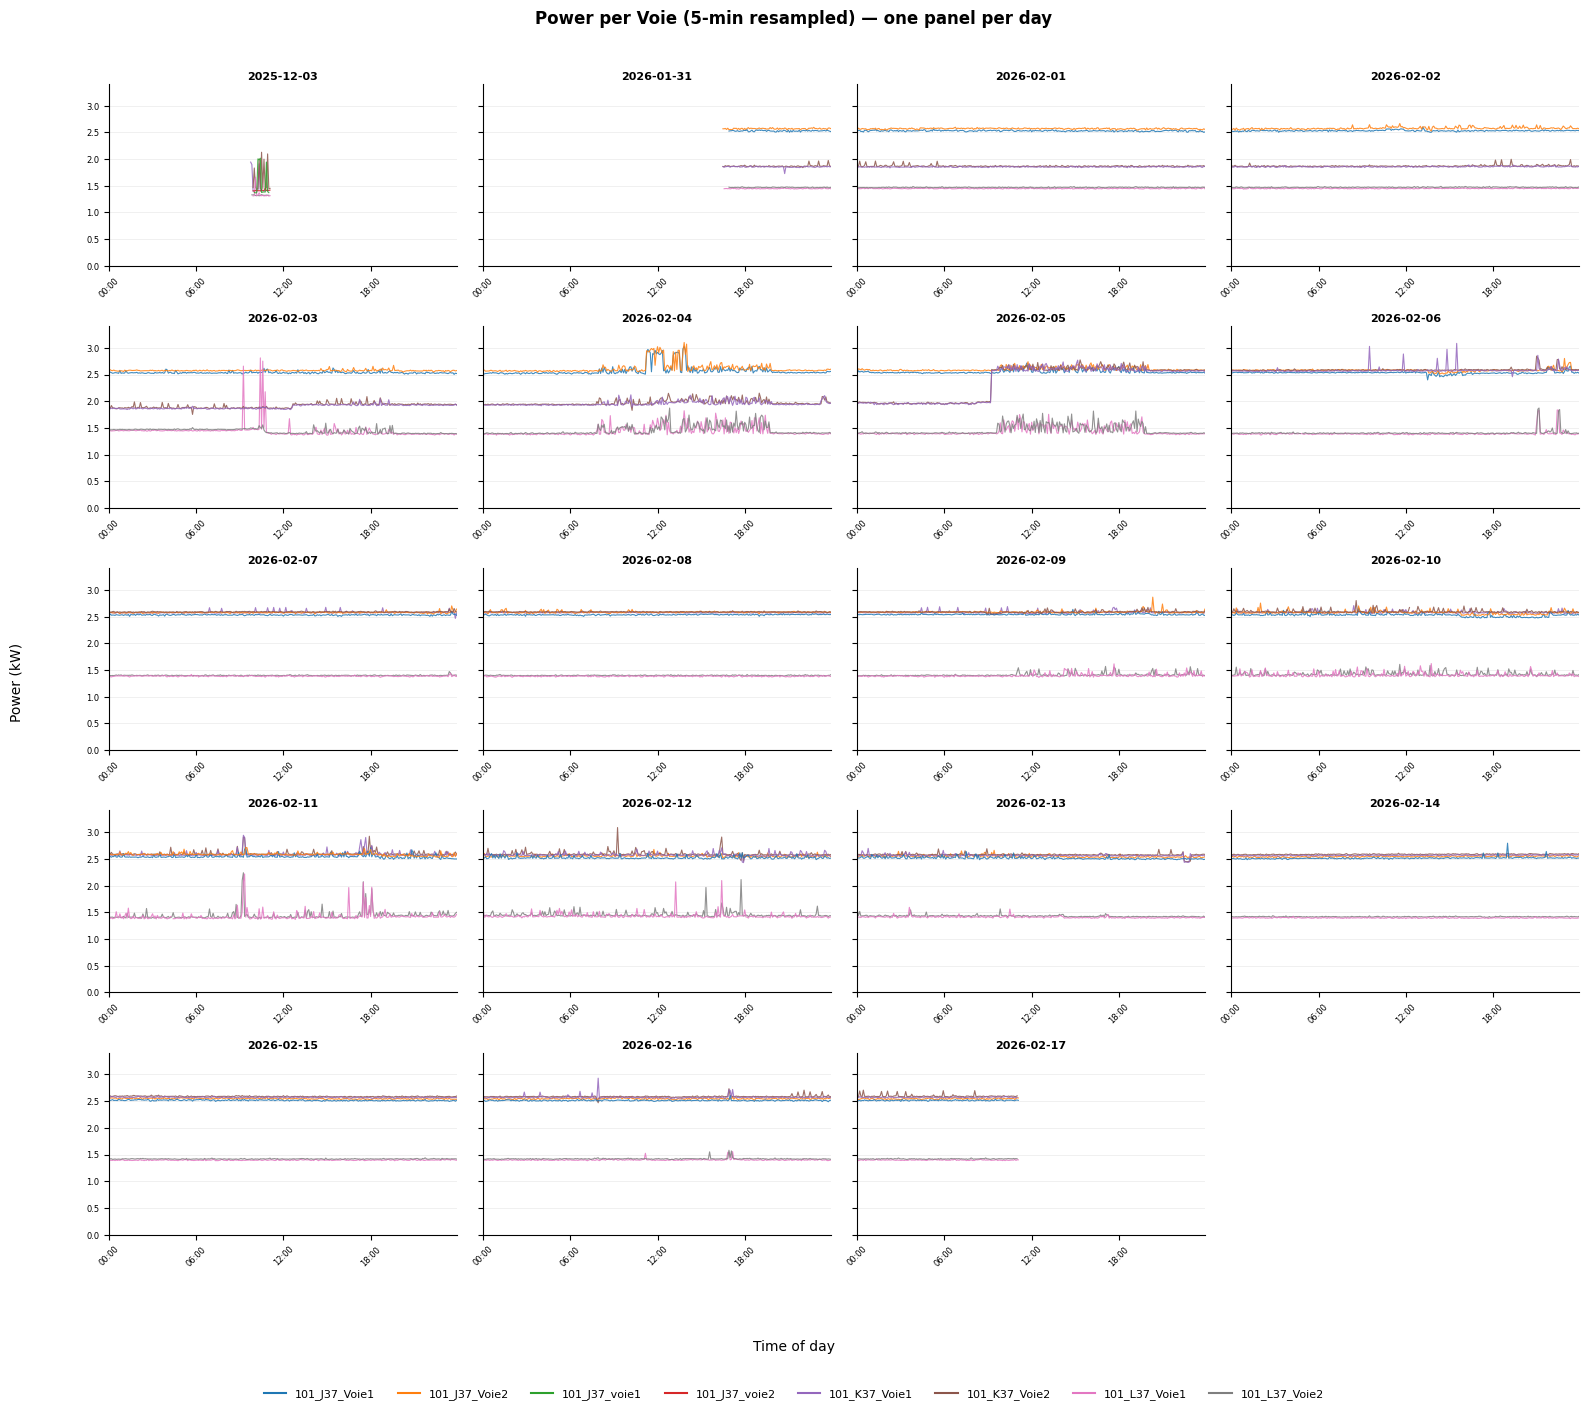

In [11]:
energy_df['Date'] = energy_df['Datetime'].dt.date

# ── Resample all days at 5-min intervals per GPU ─────────────────────────────
all_days_power = {}

for day, group in energy_df.groupby('Date'):
    voie_dict = {}
    for voie in group['GPU'].unique():
        g = group[group['GPU'] == voie].copy().set_index('Datetime')
        s = g['Input Active Power Total (W)'].resample('5min').mean() / 1000
        s.index = [pd.Timestamp.combine(pd.Timestamp('2000-01-01'), t)
                   for t in s.index.time]
        voie_dict[voie] = s
    all_days_power[day] = voie_dict

# ── Grid layout ───────────────────────────────────────────────────────────────
days   = sorted(all_days_power.keys())
n_days = len(days)
n_cols = 4
n_rows = int(np.ceil(n_days / n_cols))

voies       = sorted(energy_df['GPU'].unique())
voie_colors = {v: plt.cm.tab10.colors[i] for i, v in enumerate(voies)}

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 4, n_rows * 2.8),
    sharey=True,
    sharex=False,
)
axes = axes.flatten()

y_max = max(
    s.max()
    for voie_dict in all_days_power.values()
    for s in voie_dict.values()
) * 1.1

x_min      = pd.Timestamp('2000-01-01 00:00')
x_max      = pd.Timestamp('2000-01-01 23:55')
hour_ticks = pd.date_range('2000-01-01 00:00', '2000-01-01 23:00', freq='6h')

for i, day in enumerate(days):
    ax        = axes[i]
    voie_dict = all_days_power[day]

    for voie, s in voie_dict.items():
        ax.plot(s.index, s.values,
                color=voie_colors[voie],
                linewidth=0.8,
                alpha=0.85,
                label=voie)

    ax.set_title(str(day), fontsize=8, fontweight='bold', pad=3)
    ax.set_ylim(0, y_max)
    ax.set_xlim(x_min, x_max)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_xticks(hour_ticks)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=6)
    ax.tick_params(axis='y', labelsize=6)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# ── Single shared legend ──────────────────────────────────────────────────────
handles = [plt.Line2D([0], [0], color=voie_colors[v], linewidth=1.5, label=v)
           for v in voies]
fig.legend(handles=handles,
           loc='lower center',
           ncol=len(voies),
           fontsize=8,
           frameon=False,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Power per Voie (5-min resampled) — one panel per day',
             fontsize=12, fontweight='bold')
fig.supxlabel('Time of day', fontsize=10, y=0.02)
fig.supylabel('Power (kW)', fontsize=10, x=0.01)

plt.tight_layout(rect=[0.03, 0.05, 1, 0.97])
plt.show()

### 3.5 Total Power

These plots show the total power (power summed for all voies combined), giving the total power of the entire servers across all days with data.

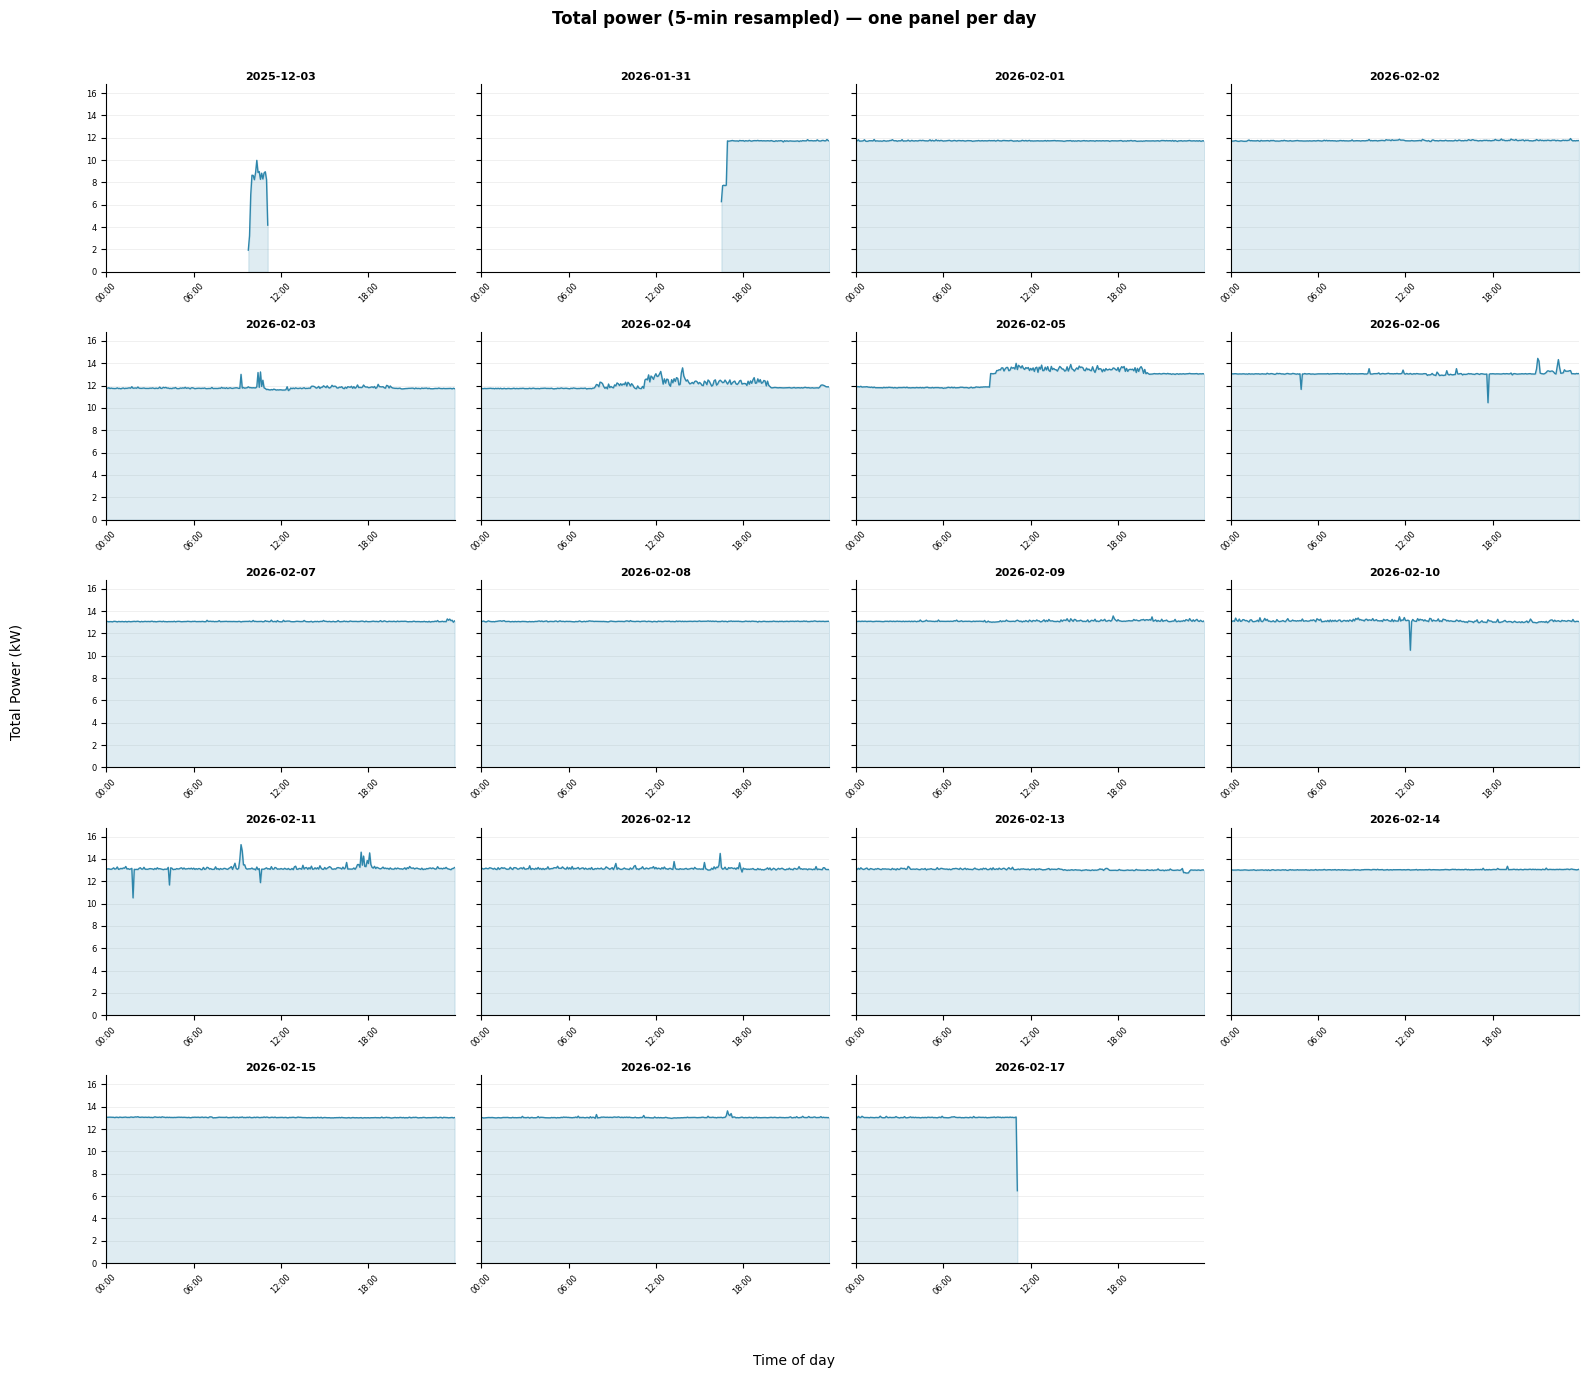

In [12]:
# ── Resample all days at 5-min intervals per GPU, then sum ───────────────────
all_days_power = []

for day, group in energy_df.groupby('Date'):
    day_list = []
    for voie in group['GPU'].unique():
        g = group[group['GPU'] == voie].copy().set_index('Datetime')
        s = g['Input Active Power Total (W)'].resample('5min').mean()
        day_list.append(s)
    if day_list:
        day_total = pd.concat(day_list, axis=1).sum(axis=1) / 1000
        all_days_power.append({'day': day, 'series': day_total})

# ── Grid layout ───────────────────────────────────────────────────────────────
n_days = len(all_days_power)
n_cols = 4
n_rows = int(np.ceil(n_days / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 4, n_rows * 2.8),
    sharey=True,
    sharex=False,
)
axes = axes.flatten()

y_max = max(entry['series'].max() for entry in all_days_power) * 1.1

# Fixed x bounds: 00:00 to 23:55 of a dummy date
x_min = pd.Timestamp('2000-01-01 00:00')
x_max = pd.Timestamp('2000-01-01 23:55')
hour_ticks = pd.date_range('2000-01-01 00:00', '2000-01-01 23:00', freq='6h')

for i, entry in enumerate(all_days_power):
    ax  = axes[i]
    day = entry['day']
    s   = entry['series']

    # Strip date, keep only time on dummy date
    s.index = [pd.Timestamp.combine(pd.Timestamp('2000-01-01'), t)
               for t in s.index.time]

    ax.plot(s.index, s.values, color='#2E86AB', linewidth=1.0)
    ax.fill_between(s.index, s.values, alpha=0.15, color='#2E86AB')

    ax.set_title(str(day), fontsize=8, fontweight='bold', pad=3)
    ax.set_ylim(0, y_max)
    ax.set_xlim(x_min, x_max)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6)
    ax.set_axisbelow(True)

    # Force ticks on every subplot
    ax.set_xticks(hour_ticks)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=6)
    ax.tick_params(axis='y', labelsize=6)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Total power (5-min resampled) — one panel per day',
             fontsize=12, fontweight='bold')

# Single x and y labels for the whole figure
fig.supxlabel('Time of day', fontsize=10, y=0.01)
fig.supylabel('Total Power (kW)', fontsize=10, x=0.01)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
plt.show()

### 3.6 Mean voie power across days

C:\Users\atheb\AppData\Local\Temp\ipykernel_19696\2953325376.py:48: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle(


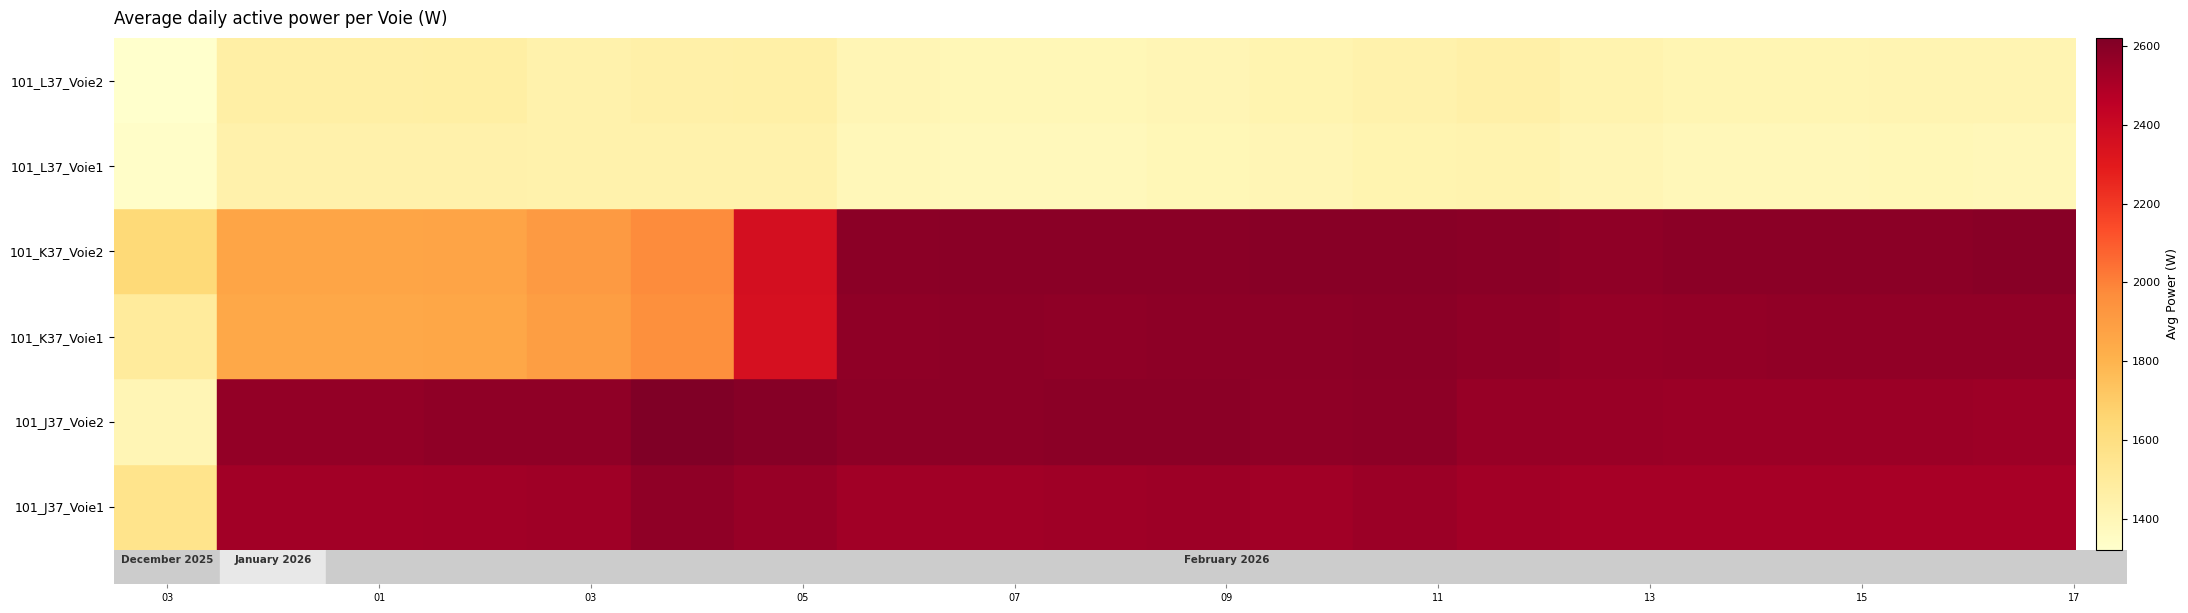

In [13]:
energy_df['GPU'] = energy_df['GPU'].str.replace(
    r'[Vv]oie', 'Voie', regex=True)

# ── Prep: daily average power per GPU ────────────────────────────────────────
power_df = energy_df[['GPU', 'Datetime', 'Input Active Power Total (W)']].copy()
power_df['Date'] = power_df['Datetime'].dt.date
power_df = power_df[power_df['Input Active Power Total (W)'] > 0]

daily_power = (
    power_df.groupby(['Date', 'GPU'])['Input Active Power Total (W)']
    .mean()
    .reset_index()
    .rename(columns={'Input Active Power Total (W)': 'Avg Power (W)'})
)
daily_power['Date'] = pd.to_datetime(daily_power['Date'])

# ── Build pivot ───────────────────────────────────────────────────────────────
# Only keep dates where at least one GPU has data
active_dates = sorted(daily_power['Date'].unique())
gpus = sorted(daily_power['GPU'].unique())

pivot = pd.DataFrame(index=gpus, columns=active_dates, dtype=float)
for _, row in daily_power.iterrows():
    pivot.loc[row['GPU'], row['Date']] = row['Avg Power (W)']

# ── Month strip data ──────────────────────────────────────────────────────────
months = pd.period_range(start=active_dates[0], end=active_dates[-1], freq='M')
month_greys = ['#CCCCCC', '#E8E8E8']

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax, ax_months) = plt.subplots(
    2, 1,
    figsize=(22, len(gpus) * 0.7 + 2),
    gridspec_kw={'height_ratios': [len(gpus), 0.4], 'hspace': 0}
)

# ── Heatmap ───────────────────────────────────────────────────────────────────
vmin = daily_power['Avg Power (W)'].min()
vmax = daily_power['Avg Power (W)'].max()
cmap = plt.cm.YlOrRd

for r, gpu in enumerate(gpus):
    for c, date in enumerate(active_dates):
        val = pivot.loc[gpu, date]
        if pd.notna(val):
            norm_val = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5
            color = cmap(norm_val)
            rect = plt.Rectangle(
                (c, r), 1, 1,
                color=color, linewidth=0.3, edgecolor='white'
            )
            ax.add_patch(rect)
        # no data = leave blank (white background)

ax.set_xlim(0, len(active_dates))
ax.set_ylim(0, len(gpus))
ax.set_yticks(np.arange(len(gpus)) + 0.5)
ax.set_yticklabels(gpus, fontsize=9)
ax.set_xticks([])
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.set_title("Average daily active power per Voie (W)",
             fontsize=12, pad=10, loc='left')

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                    fraction=0.015, pad=0.01)
cbar.set_label('Avg Power (W)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Month strip ───────────────────────────────────────────────────────────────
date_to_col = {d: i for i, d in enumerate(active_dates)}

for i, month in enumerate(months):
    # Find which active_dates fall in this month
    month_cols = [date_to_col[d] for d in active_dates
                  if d.to_period('M') == month]
    if not month_cols:
        continue
    c_start = min(month_cols)
    c_end   = max(month_cols) + 1

    ax_months.axvspan(c_start, c_end,
                      color=month_greys[i % 2], zorder=0)
    ax_months.text((c_start + c_end) / 2, 0.7,
                   month.strftime('%B %Y'),
                   ha='center', va='center',
                   fontsize=7.5, fontweight='bold', color='#333333')

# Day ticks every 2 active dates
tick_positions = [date_to_col[d] + 0.5 for d in active_dates[::2]]
tick_labels    = [d.strftime('%d') for d in active_dates[::2]]
ax_months.set_xticks(tick_positions)
ax_months.set_xticklabels(tick_labels, fontsize=7)
ax_months.set_xlim(0, len(active_dates))
ax_months.set_ylim(0, 1)
ax_months.set_yticks([])
ax_months.tick_params(axis='x', length=3, color='#888888')
ax_months.spines[["top", "right", "left", "bottom"]].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.05)
plt.show()

### 3.7 Energy consumption / day and voie

Incremental daily energy (Wh) per Voie, computed by differencing the cumulative odometer.

C:\Users\atheb\AppData\Local\Temp\ipykernel_19696\2956827353.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  energy_df = energy_df.groupby('GPU', group_keys=False).apply(filter_deltas)


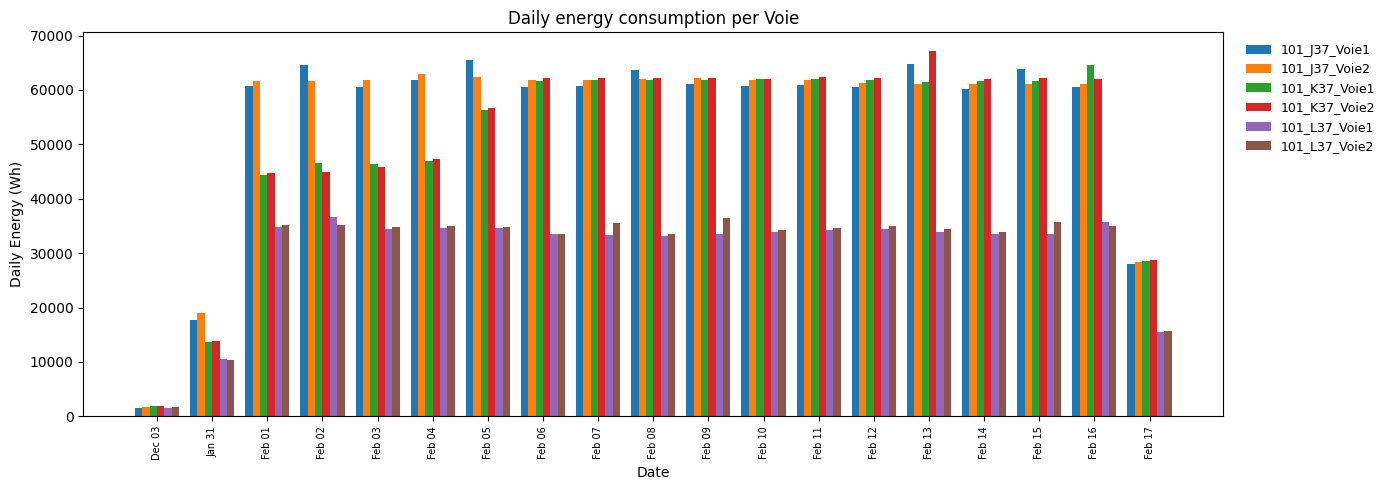

In [14]:
energy_df = energy_df.sort_values(['GPU', 'Datetime'])

energy_df['Energy Delta (Wh)'] = (
    energy_df.groupby('GPU')['Input Cumulated Energy Total (Wh)'].diff()
)

# ── Drop suspicious deltas ────────────────────────────────────────────────────
# 1. Negative deltas → odometer reset
# 2. Deltas > threshold → gap in data (accumulated over many silent days)
#    Here we cap at 2x the typical max daily value per GPU

reasonable_max = (
    energy_df[energy_df['Energy Delta (Wh)'] > 0]
    .groupby('GPU')['Energy Delta (Wh)']
    .quantile(0.95) * 3   # 3× the 95th percentile per GPU
)

def filter_deltas(group):
    gpu = group.name
    cap = reasonable_max.get(gpu, float('inf'))
    mask = (group['Energy Delta (Wh)'] > 0) & (group['Energy Delta (Wh)'] <= cap)
    group = group.copy()
    group.loc[~mask, 'Energy Delta (Wh)'] = np.nan
    return group

energy_df = energy_df.groupby('GPU', group_keys=False).apply(filter_deltas)

energy_df['Date'] = energy_df['Datetime'].dt.date

daily_energy = (
    energy_df.groupby(['Date', 'GPU'])['Energy Delta (Wh)']
    .sum()
    .reset_index()
    .rename(columns={'Energy Delta (Wh)': 'Daily Energy (Wh)'})
)

fig, ax = plt.subplots(figsize=(14, 5))

gpus = daily_energy['GPU'].unique()
dates = sorted(daily_energy['Date'].unique())
x = np.arange(len(dates))
width = 0.8 / len(gpus)

for i, gpu in enumerate(gpus):
    group = daily_energy[daily_energy['GPU'] == gpu].set_index('Date')
    values = [group.loc[d, 'Daily Energy (Wh)'] if d in group.index else 0 for d in dates]
    ax.bar(x + i * width, values, width, label=gpu)

ax.set_title('Daily energy consumption per Voie', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Energy (Wh)')
ax.set_xticks(x + width * (len(gpus) - 1) / 2)
ax.set_xticklabels([pd.Timestamp(d).strftime('%b %d') for d in dates], rotation=90, fontsize=7)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### 3.8 Comparing Energy and Tokens in February

C:\Users\atheb\AppData\Local\Temp\ipykernel_19696\298018655.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


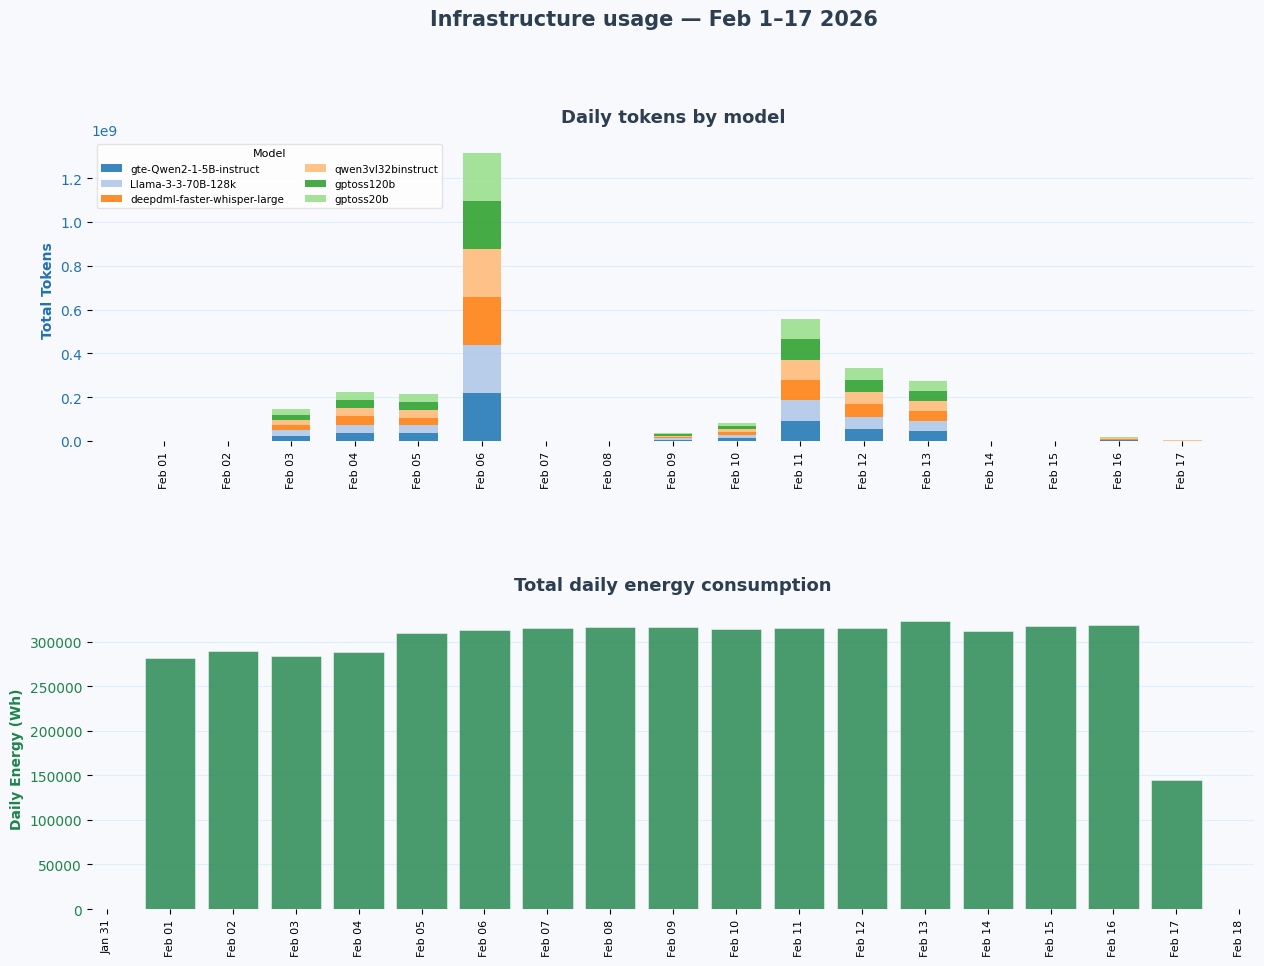

In [15]:
# ── Filter to date range ──────────────────────────────────────────────────────
start, end = pd.Timestamp('2026-02-01'), pd.Timestamp('2026-02-17')

usage_filtered = usage_df[
    (pd.to_datetime(usage_df['Date']) >= start) &
    (pd.to_datetime(usage_df['Date']) <= end)
].copy()
usage_filtered['Date'] = pd.to_datetime(usage_filtered['Date'])

energy_filtered = daily_energy[
    (pd.to_datetime(daily_energy['Date']) >= start) &
    (pd.to_datetime(daily_energy['Date']) <= end)
].copy()
energy_filtered['Date'] = pd.to_datetime(energy_filtered['Date'])

# ── Shared date axis ──────────────────────────────────────────────────────────
all_dates = pd.date_range(start, end)
date_labels = [d.strftime('%b %d') for d in all_dates]
x = np.arange(len(all_dates))

# ── Color palettes ────────────────────────────────────────────────────────────
model_colors = plt.cm.tab20.colors

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(15, 10),
    facecolor='#F7F9FC',
    gridspec_kw={'hspace': 0.55}
)
for ax in (ax_top, ax_bot):
    ax.set_facecolor('#F7F9FC')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(True, color='#DDEEFF', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ═══════════════════════════════════════════════════════════════════════════════
# TOP PLOT — Tokens stacked by model
# ═══════════════════════════════════════════════════════════════════════════════
models = usage_filtered['Model'].unique()
bar_w  = 0.6

token_bottoms = np.zeros(len(all_dates))
token_handles = []

for i, model in enumerate(models):
    color = model_colors[i % len(model_colors)]
    sub   = usage_filtered[usage_filtered['Model'] == model]
    daily = sub.groupby('Date').agg({'Total Tokens': 'sum'})

    tok_vals = np.array([
        daily.loc[d, 'Total Tokens'] if d in daily.index else 0
        for d in all_dates
    ], dtype=float)

    b1 = ax_top.bar(x, tok_vals, bar_w, bottom=token_bottoms,
                    color=color, alpha=0.88, zorder=3)
    token_bottoms += tok_vals
    token_handles.append(b1)

ax_top.set_ylabel('Total Tokens', color='#2171B5', fontsize=10, fontweight='bold')
ax_top.tick_params(axis='y', labelcolor='#2171B5')
ax_top.set_xticks(x)
ax_top.set_xticklabels(date_labels, rotation=90, fontsize=8)
ax_top.set_title('Daily tokens by model', fontsize=13,
                 fontweight='bold', color='#2C3E50', pad=12)

short_names = [m.split('/')[-1][:28] for m in models]
ax_top.legend(token_handles, short_names,
              title='Model', title_fontsize=8,
              loc='upper left', fontsize=7.5, frameon=True,
              facecolor='white', edgecolor='#DDDDDD', ncol=2)

# ═══════════════════════════════════════════════════════════════════════════════
# BOTTOM PLOT — Total daily energy (summed across all GPUs)
# ═══════════════════════════════════════════════════════════════════════════════
daily_energy_total = (
    energy_filtered.groupby('Date')['Daily Energy (Wh)']
    .sum()
    .reset_index()
)

ax_bot.bar(daily_energy_total['Date'], daily_energy_total['Daily Energy (Wh)'],
           color='#1E8449', alpha=0.8, zorder=3, edgecolor='white', linewidth=0.4)

ax_bot.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax_bot.get_xticklabels(), rotation=90, fontsize=8)
ax_bot.set_ylabel('Daily Energy (Wh)', fontsize=10, fontweight='bold', color='#1E8449')
ax_bot.tick_params(axis='y', labelcolor='#1E8449')
ax_bot.set_title('Total daily energy consumption', fontsize=13,
                 fontweight='bold', color='#2C3E50', pad=12)

fig.suptitle('Infrastructure usage — Feb 1–17 2026',
             fontsize=15, fontweight='bold', color='#2C3E50', y=1.01)

plt.tight_layout()
plt.show()